# EDA IDMT-STM-Guitar

L'exécution de ce notebook a pour prérequis :
- Le téléchargement du dataset `IDMT-SMT-Guitar`,
- le démarrage de l'infrastructure docker,
- l'ingestion du dataset `IDMT-SMT-Guitar`.

Pour télécharger le dataset `IDMT-SMT-Guitar`, utilisez la commande :
```bash
uv run ./audio_midi/main.py --download_datasets --no_guitar_set
```

Pour démarrer l'infrastructure docker, utilisez la commande :
```bash
docker-compose up -d
```

Pour lancer la pipeline d'ingestion, utilisez la commande :
```bash
uv run ./audio_midi/main.py --ingest_idmt_smt_guitar
```

## Imports

In [1]:
import sys
from pathlib import Path

AUDIO_MIDI_DIRECTORY = Path.cwd().parent
sys.path.append(AUDIO_MIDI_DIRECTORY.as_posix())

In [2]:
# Chemins
OUTPUT_DIRECTORY = AUDIO_MIDI_DIRECTORY / "output"
EDA_IDM_SMT_GUITAR_DIRECTORY = OUTPUT_DIRECTORY / "eda_idmt_smt_guitar"
FIGURES_DIRECTORY = EDA_IDM_SMT_GUITAR_DIRECTORY / "figures"
LATEX_DIRECTORY = EDA_IDM_SMT_GUITAR_DIRECTORY / "latex"

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
EDA_IDM_SMT_GUITAR_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
LATEX_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [3]:
# Imports EDA
from typing import Callable
import warnings
import pandas as pd
import numpy as np
from scipy import stats
import pretty_midi
import librosa

warnings.filterwarnings("ignore")

RANDOM_STATE = 73

In [4]:
# Imports graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Accessibilité : Daltonisme, Dyslexie, Confort Visuel
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

In [5]:
# Imports storages
import logging
from src.storages import PostgresStorage
from src.storages import MongoStorage
from src.storages import MinIOStorage

from settings import MINIO_SETTINGS

postgres = PostgresStorage(logger=logging.getLogger())
mongo = MongoStorage(logger=logging.getLogger())
minio = MinIOStorage(logger=logging.getLogger())

## Sous Dataset 2

### Métadonnées (PostgreSQL)

In [ ]:
df_metadata = pd.DataFrame(
    postgres.select_all_idmt_smt_guitar_metadata(dataset_number=2)
)
df_metadata = df_metadata.drop(columns=["id_recording", "dataset_name"])
df_metadata["recording_date"] = pd.to_datetime(df_metadata["recording_date"])
df_metadata["pick_up_setting"] = df_metadata["pick_up_setting"].map({"unknown": None})
df_metadata["instrument_body_material"] = df_metadata["instrument_body_material"].map(
    {"unknown": None}
)

df_metadata.head()

,title,instrument,instrument_model,pick_up_setting,instrument_tuning,audio_effects,recording_date,recording_artist,instrument_body_material,instrument_string_material,composer,recording_source
0,AR_A_muted5,EGUI,Aristides 010,None,40 45 50 55 59 64,None,2014-02-13,Christian Kehling,None,Steel,Christian Kehling,None
1,AR_B_fret_0-20,EGUI,Aristides 010,None,40 45 50 55 59 64,None,2014-02-13,Christian Kehling,None,Steel,Christian Kehling,None
2,AR_B_muted5,EGUI,Aristides 010,None,40 45 50 55 59 64,None,2014-02-13,Christian Kehling,None,Steel,Christian Kehling,None
3,AR_DN_III_VIII_XIV,EGUI,Aristides 010,None,40 45 50 55 59 64,None,2014-02-13,Christian Kehling,None,Steel,Christian Kehling,None
4,AR_D_fret_0-20,EGUI,Aristides 010,None,40 45 50 55 59 64,None,2014-02-13,Christian Kehling,None,Steel,Christian Kehling,None


In [16]:
df_metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype        
---  ------                      --------------  -----        
 0   title                       261 non-null    str          
 1   instrument                  261 non-null    str          
 2   instrument_model            261 non-null    str          
 3   pick_up_setting             0 non-null      object       
 4   instrument_tuning           261 non-null    str          
 5   audio_effects               0 non-null      object       
 6   recording_date              261 non-null    datetime64[s]
 7   recording_artist            261 non-null    str          
 8   instrument_body_material    0 non-null      object       
 9   instrument_string_material  261 non-null    str          
 10  composer                    261 non-null    str          
 11  recording_source            0 non-null      object       
dtypes: datetime64[s](1)

Observations :
- Les variables sont toutes catégorielles à l'exeption de `recording_date` qui est de type date.
- Les colonnes `pick_up_setting`, `audio_effects`, `instrument_body_material` et `recording_source` sont nulles.

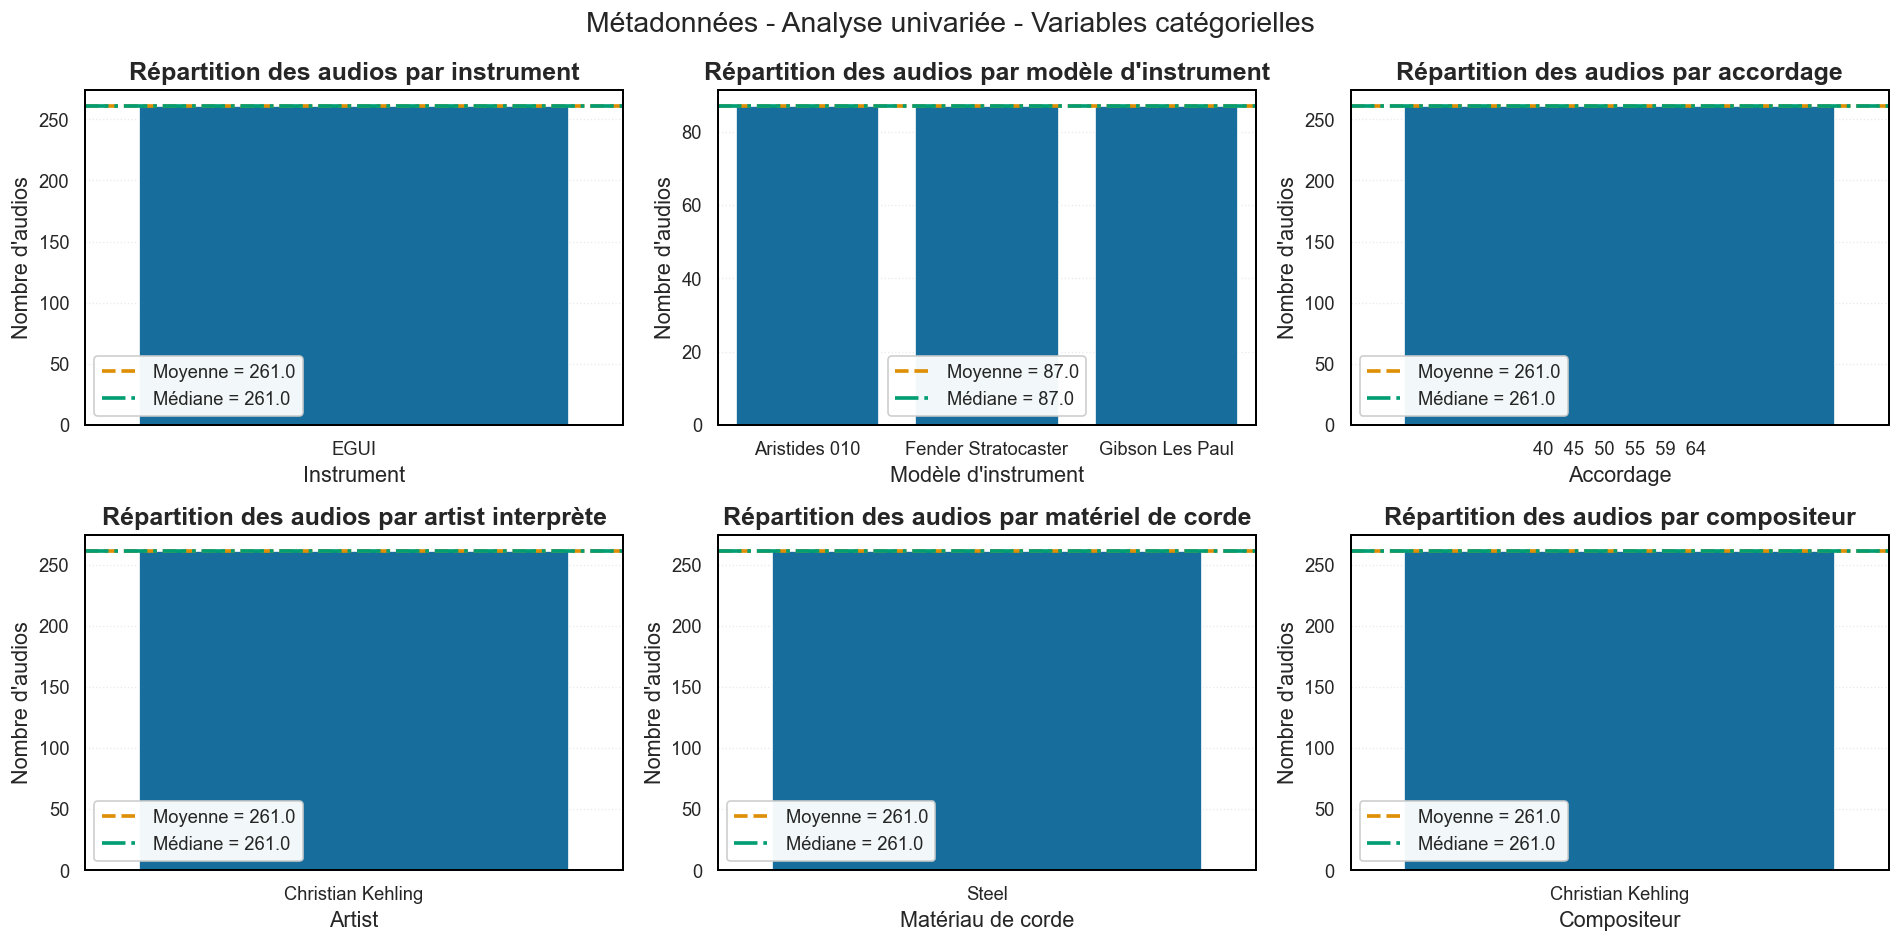

In [19]:
def create_barplot(ax, df, column, rotation=0):
    df_grpby = df.groupby(column).agg(size=(column, "size")).reset_index()

    sns.barplot(
        data=df_grpby,
        x=column,
        y="size",
        ax=ax,
    )

    mean_column = df_grpby["size"].mean()
    median_column = df_grpby["size"].median()

    ax.axhline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axhline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        label=f"Médiane = {median_column:.1f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)

    if rotation:
        ax.tick_params(axis="x", rotation=rotation)


fig, axes = plt.subplots(2, 3, figsize=(16, 8))

fig.suptitle("Métadonnées - Analyse univariée - Variables catégorielles", fontsize=17)

# ===
# Répartition des audios par instrument
# ===
ax1 = axes[0, 0]
create_barplot(ax=ax1, df=df_metadata, column="instrument")
ax1.set_title("Répartition des audios par instrument")
ax1.set_xlabel("Instrument")
ax1.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par instrument_model
# ===
ax2 = axes[0, 1]
create_barplot(ax=ax2, df=df_metadata, column="instrument_model", rotation=0)
ax2.set_title("Répartition des audios par modèle d'instrument")
ax2.set_xlabel("Modèle d'instrument")
ax2.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par instrument_tuning
# ===
ax3 = axes[0, 2]
create_barplot(ax=ax3, df=df_metadata, column="instrument_tuning")
ax3.set_title("Répartition des audios par accordage")
ax3.set_xlabel("Accordage")
ax3.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par recording_artist
# ===
ax4 = axes[1, 0]
create_barplot(ax=ax4, df=df_metadata, column="recording_artist")
ax4.set_title("Répartition des audios par artist interprète")
ax4.set_xlabel("Artist")
ax4.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par instrument_string_material
# ===
ax5 = axes[1, 1]
create_barplot(ax=ax5, df=df_metadata, column="instrument_string_material")
ax5.set_title("Répartition des audios par matériel de corde")
ax5.set_xlabel("Matériau de corde")
ax5.set_ylabel("Nombre d'audios")

# ===
# Répartition des audios par composer
# ===
ax6 = axes[1, 2]
create_barplot(ax=ax6, df=df_metadata, column="composer")
ax6.set_title("Répartition des audios par compositeur")
ax6.set_xlabel("Compositeur")
ax6.set_ylabel("Nombre d'audios")

fig.tight_layout()
plt.savefig(
    (FIGURES_DIRECTORY / "metadata_categorical_variables_distributions.png").as_posix()
)
plt.show()

Observations :
- Seul la guitare électrique (EGUI) a été utilisée pour les enregistrements.
- Trois modèles de guitare électriques sont représentés. La répartition des enregistrements est équilibrée entre les modèles de guitare électrique.
- Seul l'accordage standard a été utilisé.
- Il y a un seul interprète pour l'ensemble des audios.
- Les cordes des guitares sont dans le même matériau.
- Il y a un seul compositeur pour l'ensemble des morceaux.

### Annotations (MongoDB)

In [20]:
pipeline = [
    {"$match": {"dataset_name": "IDMT-SMT-Guitar_2"}},
    {"$count": "*"},
]

collection = "note_midi"
print(
    f"Nombre de documents dans la collection {collection} :",
    mongo.aggregate_documents(collection_name=collection, pipeline=pipeline)[0].get(
        "*", "ERROR"
    ),
)

Nombre de documents dans la collection note_midi : 261


In [39]:
pipeline = [{"$match": {"dataset_name": "IDMT-SMT-Guitar_2"}}]

title_annotations = mongo.aggregate_documents(
    collection_name="note_midi", pipeline=pipeline
)
df_annotation = pd.DataFrame(title_annotations)[["title", "transcription"]]

df_annotation = df_annotation.explode("transcription").reset_index(drop=True)
df_annotation = df_annotation.join(pd.json_normalize(df_annotation["transcription"]))
df_annotation = df_annotation.drop(columns="transcription")

df_annotation["expression_style"] = df_annotation["expression_style"].map(
    {"no_expression_sytle": None}
)
df_annotation["duration"] = df_annotation["offset"] - df_annotation["onset"]

df_annotation.head()

,title,pitch,onset,offset,fret_number,string_number,excitation_style,expression_style,loudness,modulation_frequency_range,modulation_frequency,duration
0,AR_A_fret_0-20,45,1.5790,2.2409,0,2,picked,None,None,0.0,0.0,0.6619
1,AR_A_fret_0-20,46,2.6026,3.3066,1,2,picked,None,None,0.0,0.0,0.7040
2,AR_A_fret_0-20,47,3.6949,4.3970,2,2,picked,None,None,0.0,0.0,0.7021
3,AR_A_fret_0-20,48,4.7456,5.4846,3,2,picked,None,None,0.0,0.0,0.7390
4,AR_A_fret_0-20,49,5.8514,6.5035,4,2,picked,None,None,0.0,0.0,0.6521


In [29]:
df_annotation.info()

<class 'pandas.DataFrame'>
RangeIndex: 4881 entries, 0 to 4880
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   title                       4881 non-null   str    
 1   pitch                       4881 non-null   int64  
 2   onset                       4881 non-null   float64
 3   offset                      4881 non-null   float64
 4   fret_number                 4881 non-null   int64  
 5   string_number               4881 non-null   int64  
 6   excitation_style            4881 non-null   str    
 7   expression_style            0 non-null      object 
 8   loudness                    0 non-null      object 
 9   modulation_frequency_range  4881 non-null   float64
 10  modulation_frequency        4881 non-null   float64
dtypes: float64(4), int64(3), object(2), str(2)
memory usage: 519.5+ KB


Observations :
- Les colonnes `expression_style` et `loudness` sont nulles.
- Les autres colonnes sont des variables numériques. Les titres étant considérée comme des identifiants.

In [41]:
STRINGS_MAP = {1: "E2", 2: "A2", 3: "D3", 4: "G3", 5: "B3", 6: "E4"}

STRING_ORDER = ["E2", "A2", "D3", "G3", "B3", "E4"]

df_annotation["string"] = df_annotation["string_number"].map(STRINGS_MAP)

In [42]:
pitch_range_per_string = (
    df_annotation.groupby("string")
    .agg(
        min_pitch=("pitch", "min"),
        max_pitch=("pitch", "max"),
    )
    .sort_values("min_pitch")
    .reset_index()
)

theoretical_pitch_range_per_string = pd.DataFrame(
    {
        "string": ["E2", "A2", "D3", "G3", "B3", "E4"],
        "theoretical_min_pitch": [40, 45, 50, 55, 59, 64],
        "theoretical_max_pitch": [64, 69, 74, 79, 83, 88],
    }
)

pitch_ranges = pitch_range_per_string.merge(
    theoretical_pitch_range_per_string, on="string", how="left"
)

pitch_ranges.style.hide(axis="index").format(
    decimal=",", thousands=" ", precision=2
).to_latex(buf=LATEX_DIRECTORY / "pitch_ranges.tex")

pitch_ranges[
    [
        "string",
        "min_pitch",
        "theoretical_min_pitch",
        "max_pitch",
        "theoretical_max_pitch",
    ]
].head(6).round(2)

,string,min_pitch,theoretical_min_pitch,max_pitch,theoretical_max_pitch
0,E2,40,40,68,64
1,A2,45,45,73,69
2,D3,50,50,78,74
3,G3,55,55,83,79
4,B3,59,59,87,83
5,E4,64,64,92,88


Remarque :
- Le dataset utilise plusieurs guitares électriques ayant généralement un nombre de frettes compris en 21 et 24.

Observation :
- Le pitch maximal réél est au dessus du pitch maximal théorique pour l'ensemble des cordes.

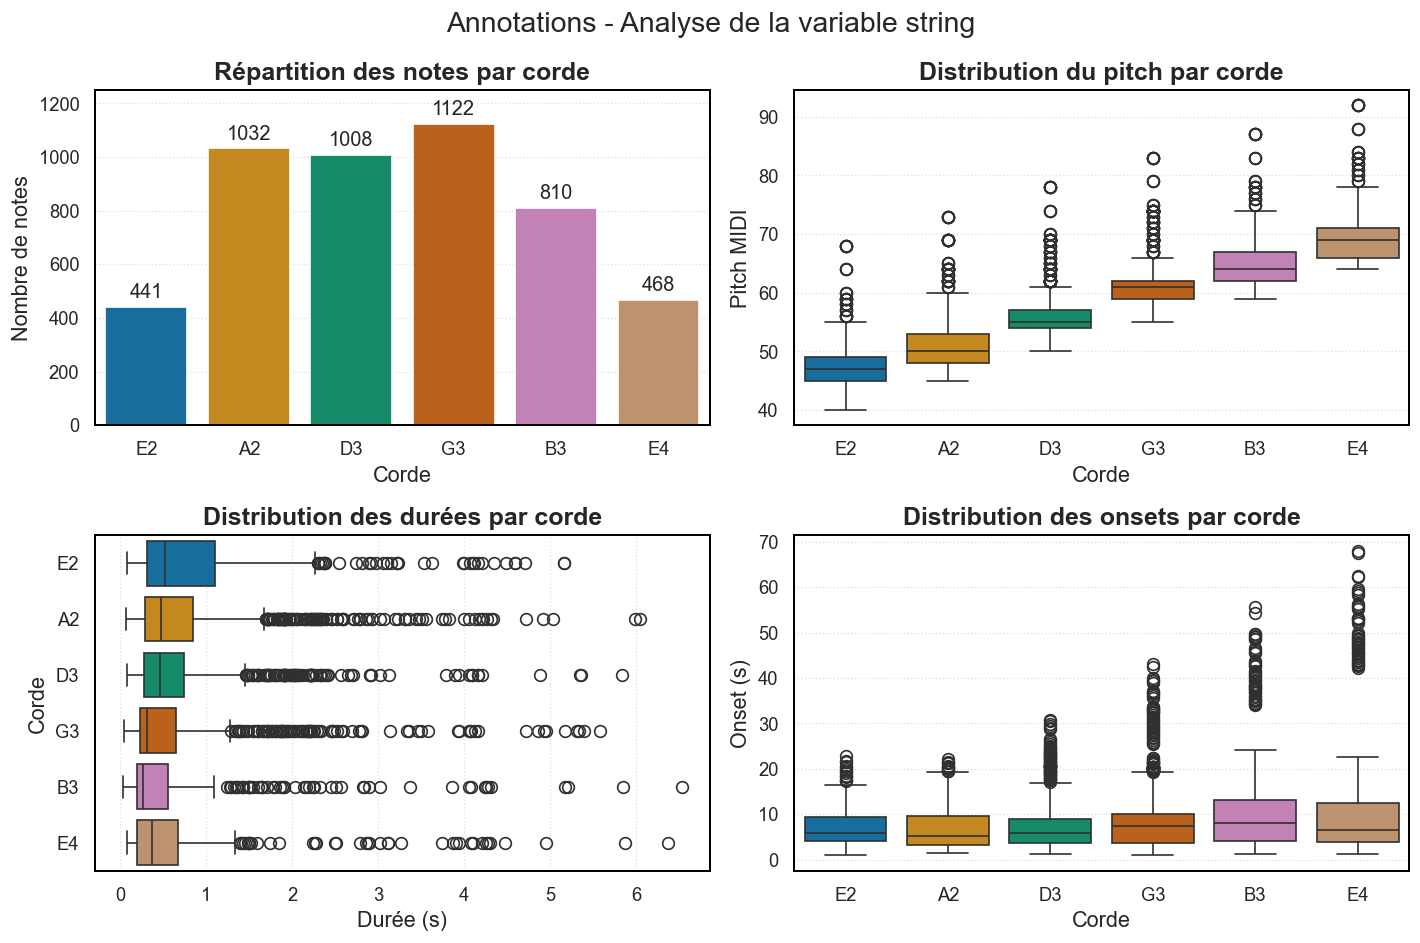

In [61]:
notes_per_string = (
    df_annotation.groupby("string")["onset"].count().reindex(STRING_ORDER)
)

string_color = {
    "E2": COLORBLIND_PALETTE[0],
    "A2": COLORBLIND_PALETTE[1],
    "D3": COLORBLIND_PALETTE[2],
    "G3": COLORBLIND_PALETTE[3],
    "B3": COLORBLIND_PALETTE[4],
    "E4": COLORBLIND_PALETTE[5],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fig.suptitle("Annotations - Analyse de la variable string", fontsize=17)

axes = axes.flatten()

# ===
# Répartition des notes par cordes
# ===
ax1 = axes[0]
barplot = sns.barplot(
    x=notes_per_string.index,
    y=notes_per_string.values,
    palette=string_color,
    hue=notes_per_string.index,
    legend=False,
    ax=ax1,
)
ax1.set_title("Répartition des notes par corde")
ax1.set_xlabel("Corde")
ax1.set_ylabel("Nombre de notes")
ax1.set_ylim(0, 1250)

for container in barplot.containers:
    labels = [f"{v:.0f}" for v in container.datavalues]
    barplot.bar_label(container, padding=3, labels=labels)

# ===
# Répartition des pitch par cordes
# ===
ax2 = axes[1]
sns.boxplot(
    data=df_annotation,
    x="string",
    y="pitch",
    order=STRING_ORDER,
    palette=string_color,
    hue="string",
    legend=False,
    ax=ax2,
)
ax2.set_xlabel("Corde")
ax2.set_ylabel("Pitch MIDI")
ax2.set_title("Distribution du pitch par corde")

# ===
# Répartition des durées par cordes
# ===
ax3 = axes[2]
sns.boxplot(
    data=df_annotation,
    x="duration",
    y="string",
    order=STRING_ORDER,
    palette=string_color,
    hue="string",
    legend=False,
    ax=ax3,
)
ax3.set_xlabel("Durée (s)")
ax3.set_ylabel("Corde")
ax3.set_title("Distribution des durées par corde")

# ===
# Répartition des onsets par cordes
# ===
ax4 = axes[3]
sns.boxplot(
    data=df_annotation,
    x="string",
    y="onset",
    order=STRING_ORDER,
    palette=string_color,
    hue="string",
    legend=False,
    ax=ax4,
)
ax4.set_xlabel("Corde")
ax4.set_ylabel("Onset (s)")
ax4.set_title("Distribution des onsets par corde")

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "annotation_data_source_analysis.png").as_posix())
plt.show()

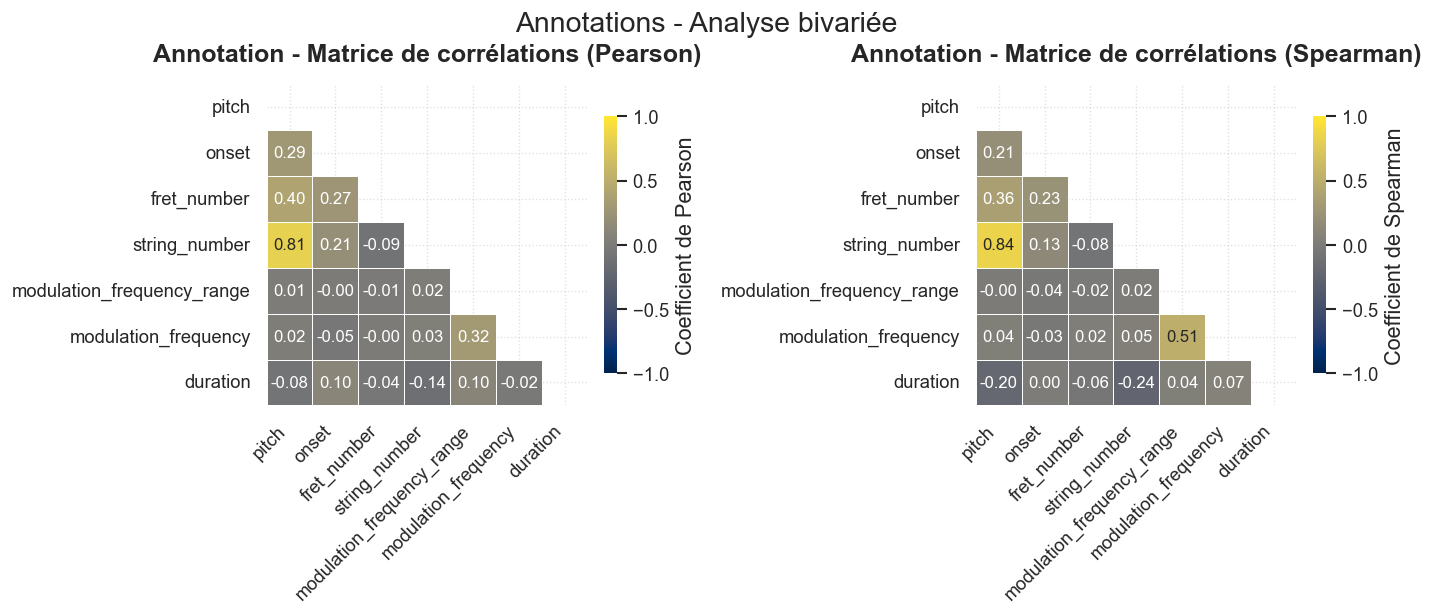

In [62]:
annotation_num_vars = [
    "pitch",
    "onset",
    "fret_number",
    "string_number",
    "modulation_frequency_range",
    "modulation_frequency",
    "duration",
]
annotation_corr_df_pearson = df_annotation[annotation_num_vars].corr(method="pearson")
annotation_corr_df_spearman = df_annotation[annotation_num_vars].corr(method="spearman")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Annotations - Analyse bivariée", fontsize=17)

# ===
# Pearson
# ===

heatmap = sns.heatmap(
    annotation_corr_df_pearson,
    mask=np.triu(np.ones_like(annotation_corr_df_pearson, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Pearson"},
    annot_kws={"size": 10},
    ax=ax1,
)
ax1.set_title("Annotation - Matrice de corrélations (Pearson)", pad=14)
ax1.set_xticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=45,
    ha="right",
)
ax1.set_yticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=0,
)

# ===
# Spearman
# ===

heatmap = sns.heatmap(
    annotation_corr_df_spearman,
    mask=np.triu(np.ones_like(annotation_corr_df_spearman, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Spearman"},
    annot_kws={"size": 10},
    ax=ax2,
)
ax2.set_title("Annotation - Matrice de corrélations (Spearman)", pad=14)
ax2.set_xticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=45,
    ha="right",
)
ax2.set_yticks(
    np.arange(0.5, len(annotation_num_vars) + 0.5, 1),
    labels=annotation_num_vars,
    rotation=0,
)

plt.tight_layout()
plt.savefig(
    (FIGURES_DIRECTORY / "annotation_numerical_variables_correlations.png").as_posix()
)
plt.show()